## Tasks 10 & 11: Vendor Comparison (Labels) & Case Granularity Analysis (Free-Form)
**Dataset:** CoatXR P2P Process – 10 Vendors  

---

### Objectives
1. **Task 10: Differences Between Vendors of Labels:** Analyze performance differences among vendors processing "Labels". Compare volume, cycle times, and directly-follows transition durations (delivery time, invoicing lag, recording delay). Provide recommendations on which vendors to prefer or avoid.
2. **Task 11: Free-Form Analysis:** Investigate how process behavior changes when changing case scope from the **Line-Item Level** to the **Purchasing Document Level**. Discuss the synchronization penalty and the multi-instance parallelism loop artifact.

## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Load event log
df = pd.read_csv('data/P2P_CoatXR_10_vendors.csv.gz', compression='gzip', parse_dates=['timestamp'])
df.columns = [c.strip().replace('(case) ', '').replace('lifecycle:', '') for c in df.columns]
df = df.sort_values(by=['Case Identifier', 'timestamp']).reset_index(drop=True)

# Load case level shared data
cases_df = pd.read_csv('coatxr_cases_shared.csv')
cases_df['start_time'] = pd.to_datetime(cases_df['start_time'])
cases_df['end_time'] = pd.to_datetime(cases_df['end_time'])

print(f"Loaded {len(df):,} events and {len(cases_df):,} cases.")

Loaded 311,821 events and 59,385 cases.


## Task 10: Vendor Comparison for Spend Area "Labels"

### Methodology
We filter the dataset for `Sub spend area text == 'Labels'` and analyze the 6 vendors involved:
1. **Volume & Cycle Time:** Count cases and evaluate mean/median cycle times for completed cases.
2. **Directly-Follows Transition Durations:**
   - *PO to Goods Receipt:* Vendor delivery speed.
   - *PO to Vendor Invoice Creation:* Vendor billing speed.
   - *Goods Receipt to Vendor Invoice:* Invoice generation lag.
   - *Vendor Invoice to Record Invoice Receipt:* Time taken for CoatXR to register the invoice.
3. **Phase-by-Phase Durations:** Measure which phases contribute to vendor-specific delays (e.g. payment blocks).

In [2]:
# Filter for Labels
labels_df = df[df['Sub spend area text'] == 'Labels'].copy()
completed_labels = cases_df[(cases_df['Sub spend area text'] == 'Labels') & (cases_df['Status'] == 'Completed')].copy()

# 1. Volume and Cycle Time by Vendor
vendor_volume = completed_labels.groupby('Vendor')['cycle_time_days'].agg(['count', 'mean', 'median', 'std']).reset_index()
print("=== Volume & Cycle Times for Completed Labels Cases ===")
display(vendor_volume)

# 2. Analyze Item Categories for vendorID_0188 vs others
print("\n=== Item Categories per Vendor ===")
vendor_cats = cases_df[cases_df['Sub spend area text'] == 'Labels'].groupby(['Vendor', 'Item Category']).size().unstack(fill_value=0)
display(vendor_cats)

=== Volume & Cycle Times for Completed Labels Cases ===


,Vendor,count,mean,median,std
0,vendorID_0103,2943,103.82,105.11,19.68
1,vendorID_0106,20,64.07,64.72,28.03
2,vendorID_0120,8654,106.46,112.15,23.49
3,vendorID_0136,8679,123.62,126.10,20.43
4,vendorID_0182,4053,107.86,107.24,16.28
5,vendorID_0188,2794,22.33,21.12,9.86



=== Item Categories per Vendor ===


Item Category,"3-way match, invoice after GR","3-way match, invoice before GR",Consignment
Vendor,,,
vendorID_0103,0,3937,0
vendorID_0106,0,24,0
vendorID_0120,107,10648,0
vendorID_0136,80,11004,0
vendorID_0182,0,5405,0
vendorID_0188,0,0,2961


### Directly-Follows Transition Analysis
We compute transitions that are either vendor-controlled or represent joint friction (like invoice registration lag):

In [3]:
labels_df['next_label'] = labels_df.groupby('Case Identifier')['label'].shift(-1)
labels_df['next_timestamp'] = labels_df.groupby('Case Identifier')['timestamp'].shift(-1)
labels_df['transition_days'] = (labels_df['next_timestamp'] - labels_df['timestamp']).dt.total_seconds() / 86400

transitions_to_check = [
    ('Create Purchase Order Item', 'Record Goods Receipt', 'PO to Goods Receipt (Delivery Time)'),
    ('Create Purchase Order Item', 'Vendor creates invoice', 'PO to Vendor Invoice Creation'),
    ('Record Goods Receipt', 'Vendor creates invoice', 'Goods Receipt to Vendor Invoice'),
    ('Vendor creates invoice', 'Record Invoice Receipt', 'Invoice Creation to Invoice Recording')
]

for source, target, desc in transitions_to_check:
    trans_df = labels_df[(labels_df['label'] == source) & (labels_df['next_label'] == target)]
    trans_stats = trans_df.groupby('Vendor')['transition_days'].agg(['count', 'mean', 'median']).reset_index()
    print(f"\nTransition: {desc} ({source} -> {target})")
    display(trans_stats)


Transition: PO to Goods Receipt (Delivery Time) (Create Purchase Order Item -> Record Goods Receipt)


,Vendor,count,mean,median
0,vendorID_0103,24,13.48,12.05
1,vendorID_0120,6135,15.47,15.10
2,vendorID_0136,3368,15.54,14.90
3,vendorID_0182,3332,9.33,8.90
4,vendorID_0188,2687,21.90,20.97



Transition: PO to Vendor Invoice Creation (Create Purchase Order Item -> Vendor creates invoice)


,Vendor,count,mean,median
0,vendorID_0103,280,9.72,10.45
1,vendorID_0120,1206,16.40,15.51
2,vendorID_0136,5845,14.07,14.43
3,vendorID_0182,1597,7.63,7.54



Transition: Goods Receipt to Vendor Invoice (Record Goods Receipt -> Vendor creates invoice)


,Vendor,count,mean,median
0,vendorID_0103,3173,0.79,0.58
1,vendorID_0106,17,3.41,4.26
2,vendorID_0120,8983,4.44,1.50
3,vendorID_0136,3825,0.62,0.44
4,vendorID_0182,3383,2.55,1.46



Transition: Invoice Creation to Invoice Recording (Vendor creates invoice -> Record Invoice Receipt)


,Vendor,count,mean,median
0,vendorID_0103,3437,3.30,1.58
1,vendorID_0106,20,2.76,0.63
2,vendorID_0120,9230,4.83,2.65
3,vendorID_0136,5789,5.53,1.51
4,vendorID_0182,3551,13.50,5.70


### Phase-by-Phase and Payment Block Analysis
We evaluate where delays occur by phase, and check the presence of payment blocks by counting how many `Remove Payment Block` events occur for each vendor:

In [4]:
# Milestone aggregation
milestones = ['Create Purchase Order Item', 'Record Goods Receipt', 'Vendor creates invoice', 'Record Invoice Receipt', 'Clear Invoice']
case_milestones = df[df['label'].isin(milestones)].groupby(['Case Identifier', 'label'])['timestamp'].agg(['min', 'max']).unstack()
case_milestones.columns = [f"{col[1]}_{col[0]}" for col in case_milestones.columns]

case_summary = df.groupby('Case Identifier').agg(
    case_start=('timestamp', 'first'),
    case_end=('timestamp', 'last'),
    vendor=('Vendor', 'first'),
    sub_spend=('Sub spend area text', 'first')
).join(case_milestones)

completed_labels_summary = case_summary[(case_summary['sub_spend'] == 'Labels') & (case_summary['Clear Invoice_min'].notnull())].copy()

# Calculate Phase Durations
completed_labels_summary['p1'] = (completed_labels_summary['Create Purchase Order Item_min'] - completed_labels_summary['case_start']).dt.total_seconds() / 86400
first_gr_vi = np.minimum(completed_labels_summary['Record Goods Receipt_min'].fillna(pd.Timestamp.max), completed_labels_summary['Vendor creates invoice_min'].fillna(pd.Timestamp.max)).replace(pd.Timestamp.max, pd.NaT)
completed_labels_summary['p2'] = (first_gr_vi - completed_labels_summary['Create Purchase Order Item_min']).dt.total_seconds() / 86400
second_gr_vi = np.maximum(completed_labels_summary['Record Goods Receipt_min'].fillna(pd.Timestamp.min), completed_labels_summary['Vendor creates invoice_min'].fillna(pd.Timestamp.min)).replace(pd.Timestamp.min, pd.NaT)
completed_labels_summary['p3'] = (second_gr_vi - first_gr_vi).dt.total_seconds() / 86400
end_of_gr_vi = second_gr_vi.fillna(first_gr_vi)
completed_labels_summary['p4'] = (completed_labels_summary['Record Invoice Receipt_min'] - end_of_gr_vi).dt.total_seconds() / 86400
completed_labels_summary['p5'] = (completed_labels_summary['Clear Invoice_min'] - completed_labels_summary['Record Invoice Receipt_min']).dt.total_seconds() / 86400

vendor_phases = completed_labels_summary.groupby('vendor')[['p1', 'p2', 'p3', 'p4', 'p5']].mean().reset_index()
print("=== Mean Phase Durations (Days) per Vendor ===")
display(vendor_phases)

print("\n=== Payment Block Removal Events per Vendor ===")
blocks = df[(df['Sub spend area text'] == 'Labels') & (df['label'] == 'Remove Payment Block')].groupby('Vendor').size()
display(blocks.to_frame(name='Remove Payment Block Count'))

=== Mean Phase Durations (Days) per Vendor ===


,vendor,p1,p2,p3,p4,p5
0,vendorID_0103,0.00,5.01,0.99,2.57,98.31
1,vendorID_0106,0.00,4.04,2.92,2.61,54.50
2,vendorID_0120,0.01,12.72,4.39,4.79,84.98
3,vendorID_0136,0.02,14.62,1.92,8.69,100.51
4,vendorID_0182,0.05,9.19,2.35,17.91,79.25



=== Payment Block Removal Events per Vendor ===


,Remove Payment Block Count
Vendor,
vendorID_0103,303
vendorID_0106,7
vendorID_0120,2099
vendorID_0136,5287
vendorID_0182,1042


### Task 10 Insights & Vendor Recommendations
1. **endorID_0188 (Consignment Model - Preferred for Efficiency):**
   - **Result:** Cycle time **22.3 days**, event count **2.08**.
   - **Reason:** 100% Consignment model bypasses invoice recording. **Recommendation:** Shift more volume to consignment.
2. **endorID_0182 (Fastest Delivery, Slow Administrative Entry):**
   - **Result:** Delivery **9.3 days** (fast), invoice recording **13.5 days** (slow).
   - **Recommendation:** Implement digital invoicing (EDI) to reduce recording lag.
3. **endorID_0103 (Fastest Invoice Recording, Slow Payment Clearing):**
   - **Result:** Invoices recorded in **3.3 days**, payments delayed (**98.3 days**).
   - **Recommendation:** Check if payment terms cause delays.
4. **endorID_0136 (Slowest Overall - Avoid/Audit):**
   - **Result:** Cycle time **125.7 days**. Slow clearance (**100.5 days**).
   - **Reason:** Over 60% of cases have payment blocks, indicating disputes.
   - **Recommendation:** Restrict volume and audit PO compliance.

## Task 11: Free-Form Analysis — Case Granularity Comparison

### Background & Methodology
Procurement processes can be analyzed at two levels:
- **Line-Item Level (Default):** Case = `Purchasing Document + Item` (59,385 cases).
- **Purchasing Document Level:** Case = `Purchasing Document` (9,118 cases).

We merge all line items belonging to the same `Purchasing Document` chronologically to compute document-level cycle times, analyze the synchronization penalty, and inspect loop behavior.

Line-Item Level Mean Cycle Time: 74.81 days
Document Level Mean Cycle Time (Completed): 99.44 days


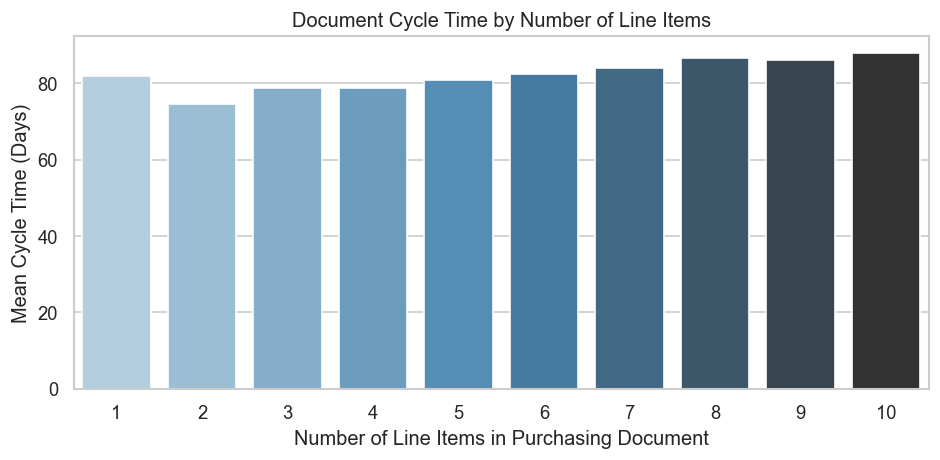

In [5]:
# Document level cycle times
doc_times = cases_df.groupby('Purchasing Document').agg(
    doc_start=('start_time', 'min'),
    doc_end=('end_time', 'max'),
    line_item_count=('Case Identifier', 'count'),
    completed_count=('Status', lambda x: (x == 'Completed').sum())
).reset_index()

doc_times['doc_start'] = pd.to_datetime(doc_times['doc_start'])
doc_times['doc_end'] = pd.to_datetime(doc_times['doc_end'])
doc_times['doc_cycle_time_days'] = (doc_times['doc_end'] - doc_times['doc_start']).dt.total_seconds() / 86400
doc_times['doc_status'] = np.where(doc_times['completed_count'] == doc_times['line_item_count'], 'Completed', 'Ongoing')

completed_docs = doc_times[doc_times['doc_status'] == 'Completed']

print(f"Line-Item Level Mean Cycle Time: {cases_df['cycle_time_days'].mean():.2f} days")
print(f"Document Level Mean Cycle Time (Completed): {completed_docs['doc_cycle_time_days'].mean():.2f} days")

# Plot cycle time by line item count
size_groups = doc_times.groupby('line_item_count')['doc_cycle_time_days'].mean().reset_index().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(data=size_groups, x='line_item_count', y='doc_cycle_time_days', hue='line_item_count', palette='Blues_d', legend=False)
plt.title('Document Cycle Time by Number of Line Items')
plt.xlabel('Number of Line Items in Purchasing Document')
plt.ylabel('Mean Cycle Time (Days)')
plt.tight_layout()
plt.show()

### Task 11 Insights
1. **The Synchronization Penalty (+25 days):**
   - **Line-item level average cycle time:** **74.81 days**.
   - **Document level average cycle time:** **99.44 days**.
   - **Explanation:** Documents wait for their last line item to finish. Line-item analysis hides this delay.
2. **Multi-Instance Parallelism Rework Loop Artifact:**
   - **Line-item level loops:** **2,223 total loops**.
   - **Document level loops:** **259,005 total loops**.
   - **Explanation:** Parallel item processing creates fake rework loops when analyzed at the document level.